<a href="https://colab.research.google.com/github/Uma17/Data-Science/blob/main/AdvancedML_EasyVisa_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

 Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


# **Loading the dataset**

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Overview of the Dataset**

In [ ]:
easy_visa=pd.read_csv("/content/drive/MyDrive/projects/AdvancedML/EasyVisa.csv")

The data set is loaded from EasyVisa.csv

## Read rows

In [ ]:
easy_visa.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
easy_visa.sample(n=20, random_state=22)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
12764,EZYV12765,Asia,Bachelor's,Y,N,640,1996,Midwest,125377.72,Year,Y,Certified
20846,EZYV20847,Oceania,Doctorate,Y,N,1481,1986,Northeast,132818.80,Year,Y,Certified
5595,EZYV5596,Asia,High School,Y,N,1515,1999,South,16143.99,Year,Y,Denied
1838,EZYV1839,North America,Bachelor's,Y,N,4297,1986,South,42039.37,Year,Y,Certified
22607,EZYV22608,Asia,High School,Y,Y,3262,2007,Northeast,65008.86,Year,Y,Certified
11276,EZYV11277,North America,Bachelor's,N,N,2979,1998,Northeast,86665.46,Year,N,Denied
4075,EZYV4076,Asia,Master's,Y,N,1513,2007,West,25425.47,Year,Y,Certified
23710,EZYV23711,North America,Doctorate,Y,N,727,1938,Northeast,5704.88,Year,Y,Certified
15889,EZYV15890,Asia,Bachelor's,N,N,559,2000,South,59005.42,Year,Y,Certified
9383,EZYV9384,Africa,Master's,N,N,699,1987,Northeast,103119.78,Year,Y,Certified


Observation:
Check randomly for any inconsistent labels or data

## count rows and columns

In [ ]:
print("Rows:", easy_visa.shape[0])
print("Columns:", easy_visa.shape[1])

Rows: 25480
Columns: 12


## Get data types of columns

In [ ]:
easy_visa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Observation: No missing value

* numeric variables are : no_of_employees, yr-of-estab,prevailing wage
* categorical variables including binary are: case_id, continent, education, job_experience, requires job training, Y/N, region of employment, unitof wage, full time position(y/n), case status

numeric-no_of_employees, yr-of-estab,prevailing wage

categorical-case_id, continent, education, , requires job training, Y/N, region of employment, unitof wage, full time position(y/n), case status

binary - has job_experience, require job training, fulltime position

## verify for null values

In [ ]:
easy_visa.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


Observation:
There are no null values in the dataset

In [ ]:
easy_visa.nunique().sum()

np.int64(58265)

## verify for duplicated values

In [ ]:
easy_visa.duplicated().sum()

np.int64(0)

## copy data in new set

In [ ]:
data=easy_visa.copy()

Observation:
case_id can be  dropped during data preprocessing as it is unique ID which  does not add any value to  data

In [ ]:
data.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [ ]:
data.select_dtypes(include='object').columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

Observation:
List out all the categorical values of object data type

In [ ]:
cols= ['continent','education_of_employee']
for col in cols:
    print(f"Unique values for {col}: {data[col].unique()}")


Unique values for continent: ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
Unique values for education_of_employee: ['High School' "Master's" "Bachelor's" 'Doctorate']


In [ ]:
data['continent'].value_counts()

,count
continent,
Asia,16861
Europe,3732
North America,3292
South America,852
Africa,551
Oceania,192


In [ ]:
data['education_of_employee'].value_counts()

,count
education_of_employee,
Bachelor's,10234
Master's,9634
High School,3420
Doctorate,2192


In [ ]:
data[['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status']].apply(lambda x: x.unique())

,0
continent,"[Asia, Africa, North America, Europe, South Am..."
education_of_employee,"[High School, Master's, Bachelor's, Doctorate]"
has_job_experience,"[N, Y]"
requires_job_training,"[N, Y]"
region_of_employment,"[West, Northeast, South, Midwest, Island]"
unit_of_wage,"[Hour, Year, Week, Month]"
full_time_position,"[Y, N]"
case_status,"[Denied, Certified]"


Observation:
Fetch up the values of variables - continent, education_of_employee, which helps to find for any inconsistent ,duplicated and invalid datas

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


Observation:
Calculate statistical summary like mean,std, minimum , maximum values
* no_of employees  carries negative value,
which should be taken care during data preprocessing
*  prevailing wage  range from minimum of $2 to max of 319210.27 , which is vast difference in values, need to check the units of the numeric, scaling may be needed during data preprocessing




# **Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

## functions for histogramboxplot

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

## function for labeled barplot

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

# Univariate

## continent

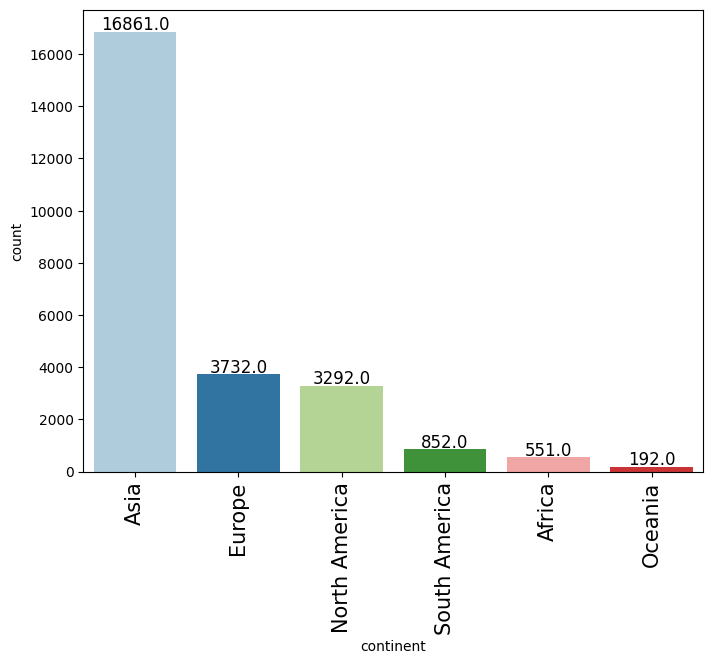

In [ ]:
labeled_barplot(data, "continent")

Observation:
* Asia has the most applicants
* Europe and NorthAmerica has similar applicant rate




## education_of_employee

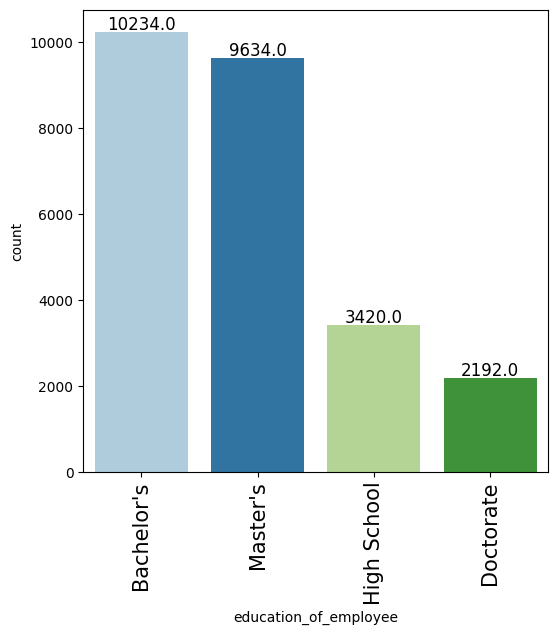

In [ ]:
labeled_barplot(data, "education_of_employee")

Observation:
* High  applicants are graduated bachelors =10234 and similar number of graduated in master's=9634
*  Doctorate applicants are minimal.



## has_job_experience

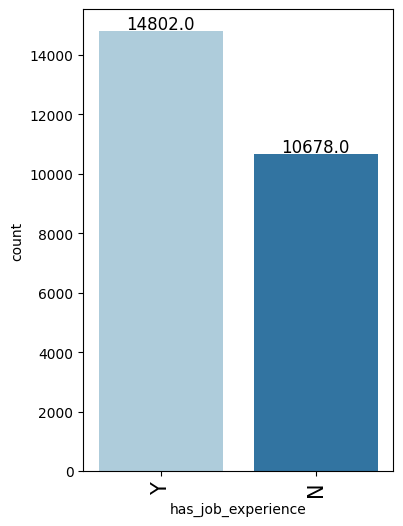

In [ ]:
labeled_barplot(data, "has_job_experience")

Observation:
Experienced -14802
Non experienced- 10678

## requires_job_training

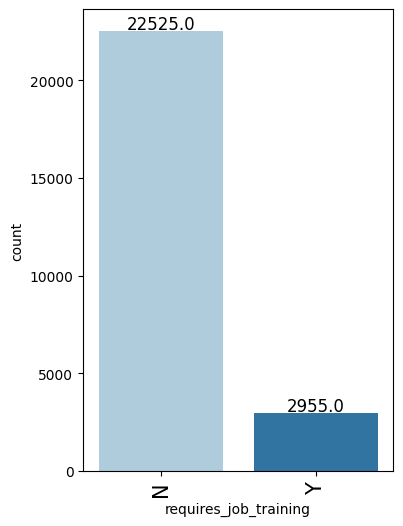

In [ ]:
labeled_barplot(data, "requires_job_training")

Observation:
* 22525 applicants doent need training
* 2955 applicants need training



## yr_of_estab,no_of_employees,prevailing_wage

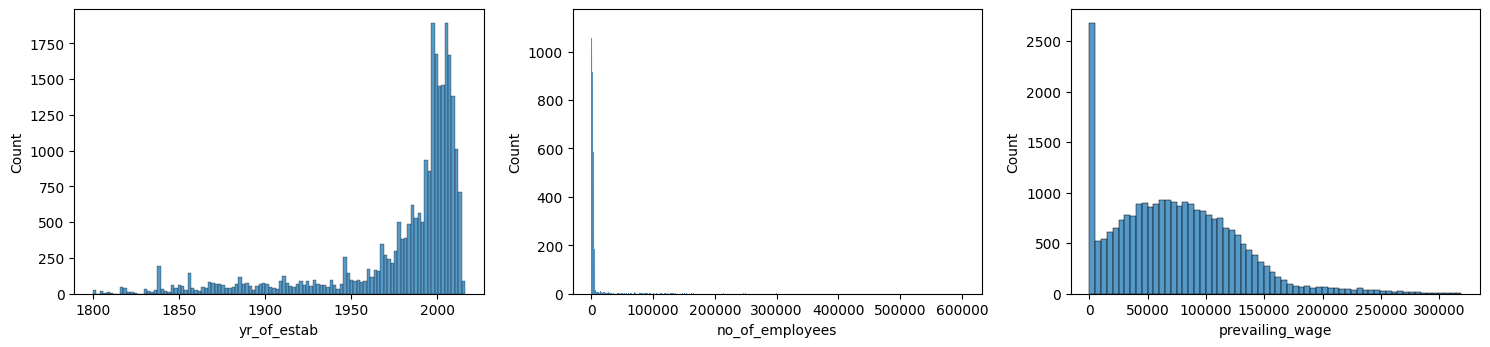

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))
# defining the list of numerical features to plot
num_features = ['yr_of_estab','no_of_employees','prevailing_wage']
# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram
plt.tight_layout();   # to add spacing between plots

## yr_of_estab

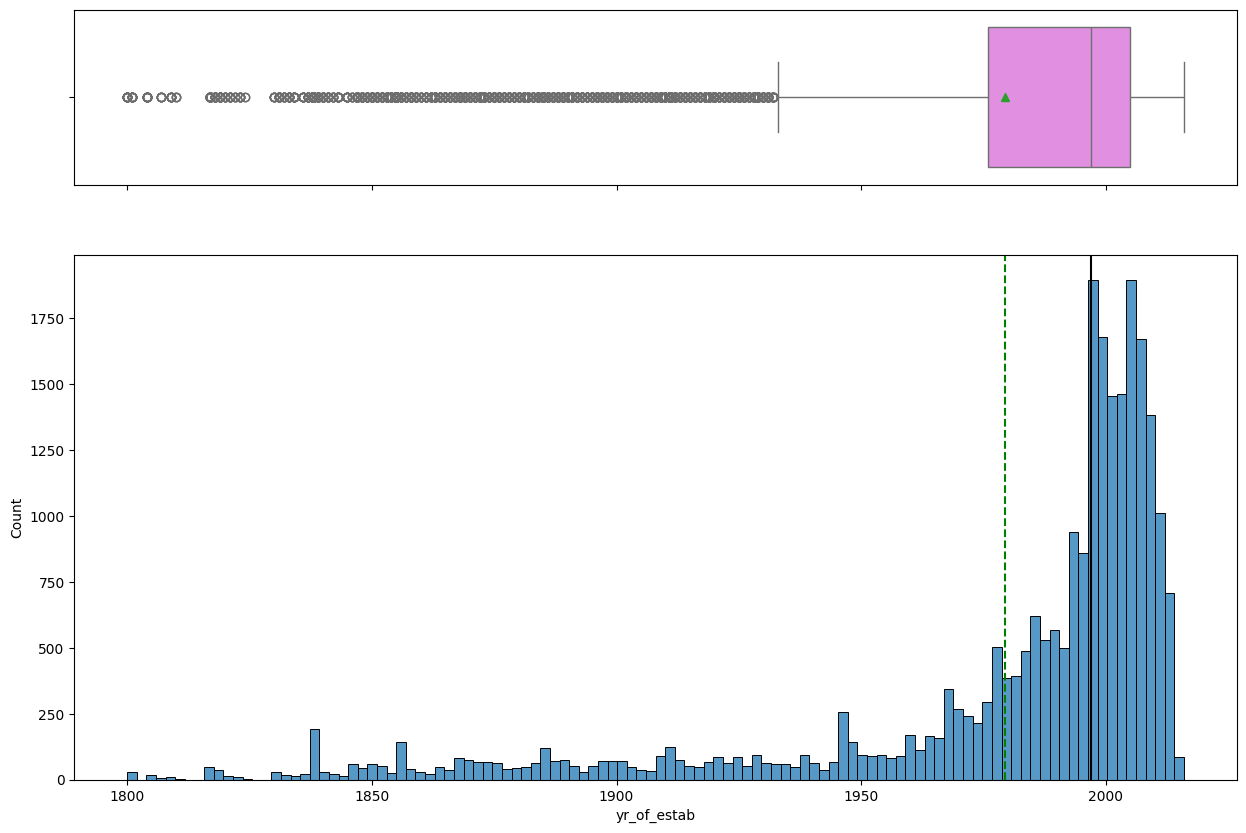

In [ ]:
histogram_boxplot(data, "yr_of_estab")

Observation:
* There are so many outliers during earlier year, which can be handled  during Data preprocessing
The boxplot is left skewed

In [ ]:
Q1=data['yr_of_estab'].quantile(0.25)
Q3 = data['yr_of_estab'].quantile(0.75)
IQR= Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
data_out=data[(data['yr_of_estab']>=lower) & (data['yr_of_estab']<=upper)]
data_out['yr_of_estab'].value_counts()


,count
yr_of_estab,
1998,1134
2005,1051
2001,1017
2007,994
1999,870
2004,846
2006,844
2000,806
1997,761


In [ ]:
from datetime import datetime
current_year = datetime.now().year
data['company_age'] = current_year - data['yr_of_estab']
data['company_age']


,company_age
0,19
1,24
2,18
3,129
4,21
...,...
25475,18
25476,20
25477,116
25478,139


In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


## company_age

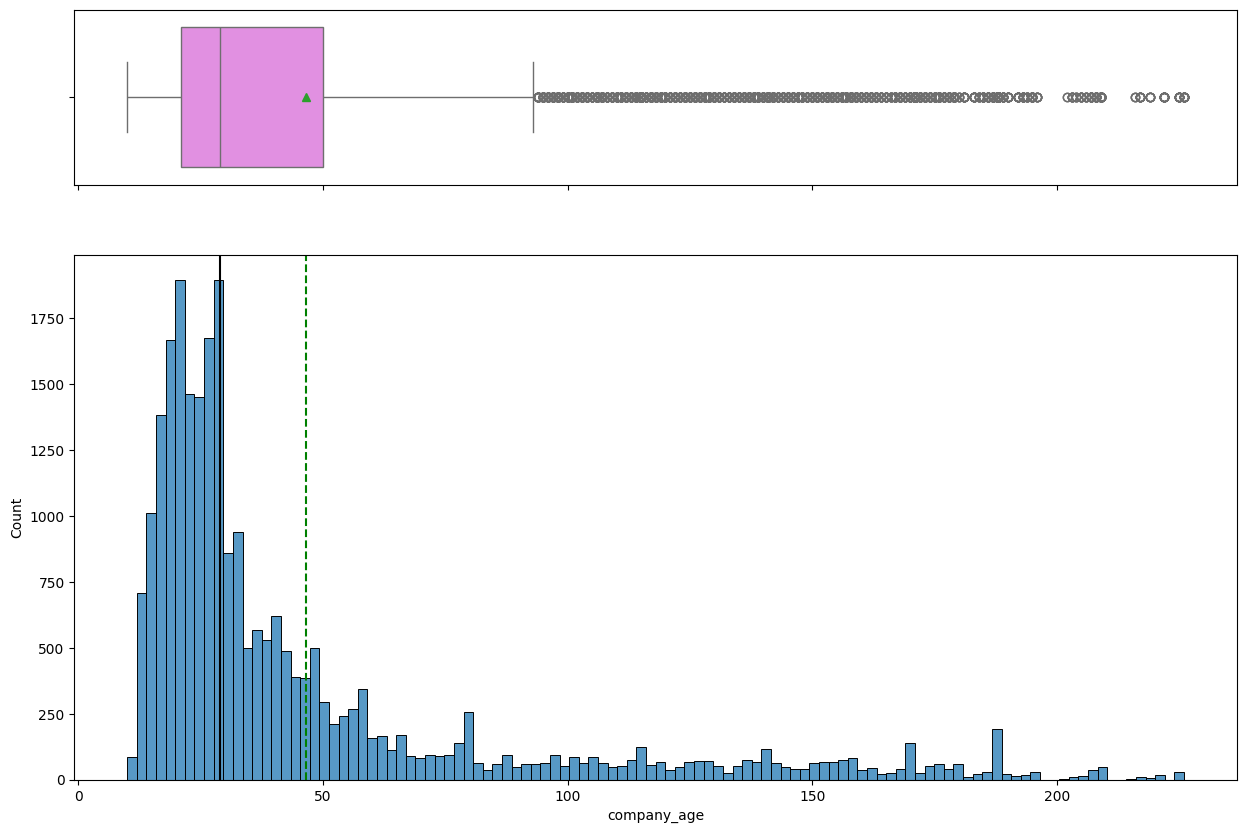

In [ ]:
histogram_boxplot(data, "company_age")

## prevailing_wage

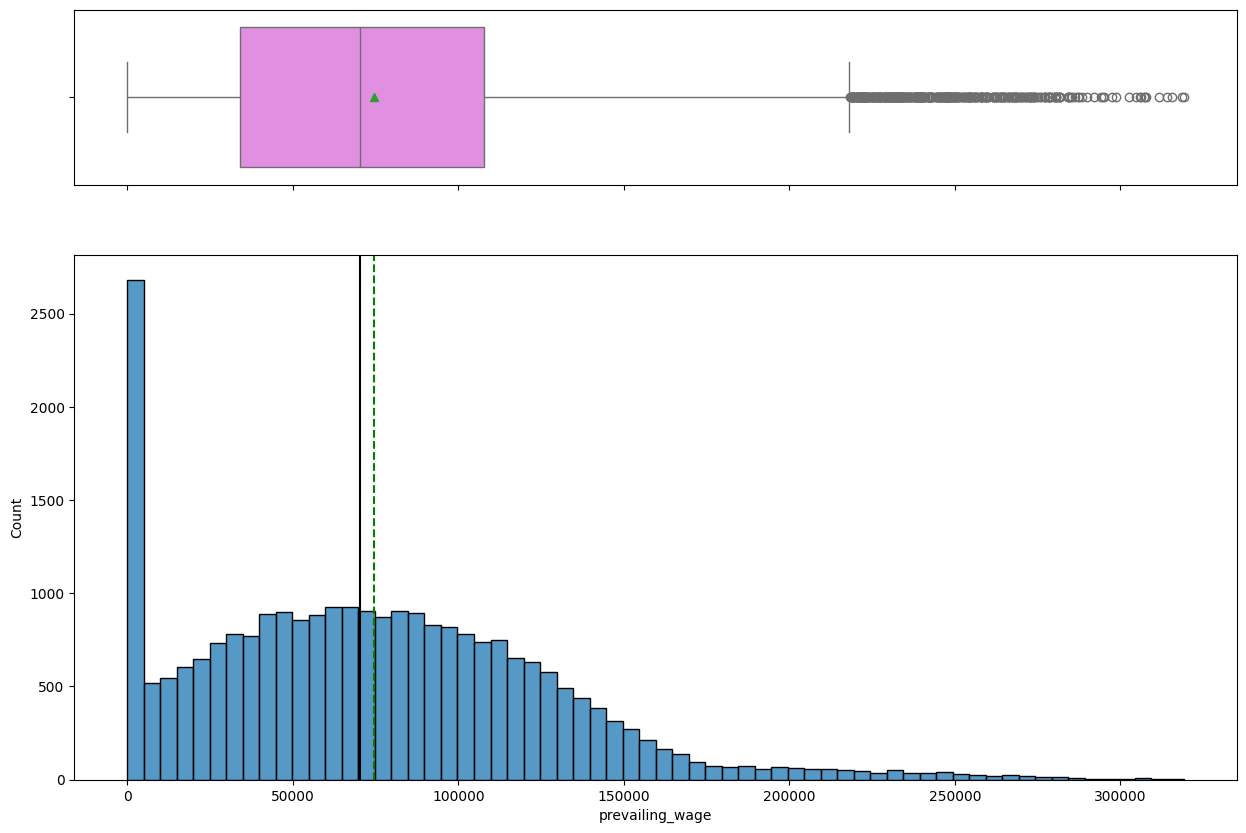

In [ ]:
histogram_boxplot(data, "prevailing_wage")

Observation

* A huge spike at 0,  a long tail and many outliers
* Prevailing wage is not so good at predicting. How ever it mayneed to compute with unit of wage to to form annual wage.



## unit_of_wage

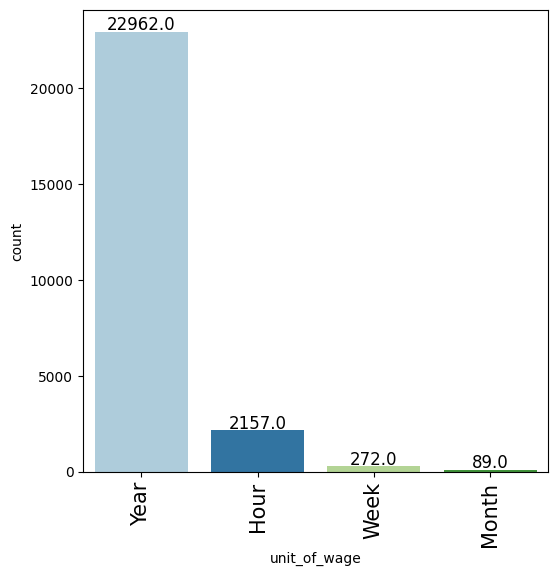

In [ ]:
labeled_barplot(data, "unit_of_wage")

Observation

* Unit Of wage is not strong predictor .Yearly count is peak to 22962


## no_of_employees

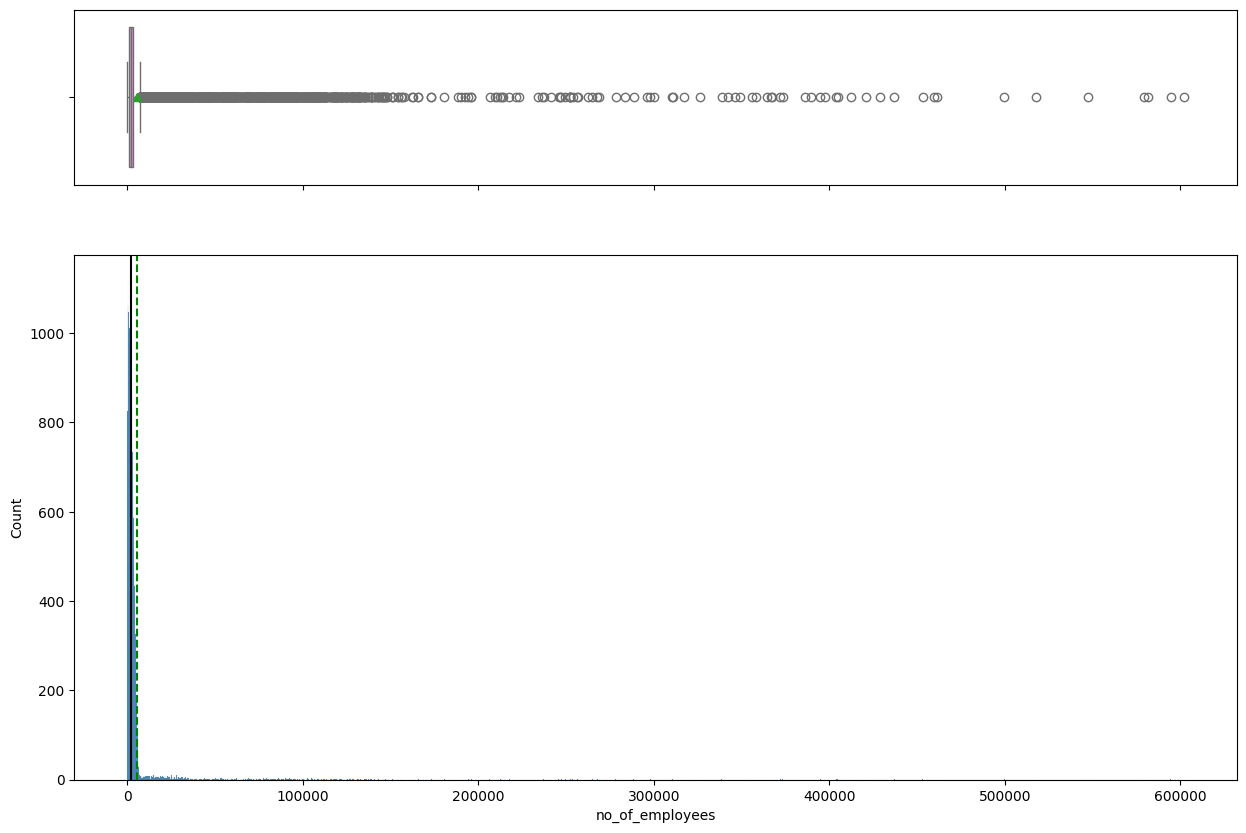

In [ ]:
histogram_boxplot(data, "no_of_employees")

Observation:

* The ditribution is not clear and boxplot is rarely seenwith most of outliers.
*  Inorder to make it more readable, log function is used to  handle zeros in no_of_employees



## outlier-log function

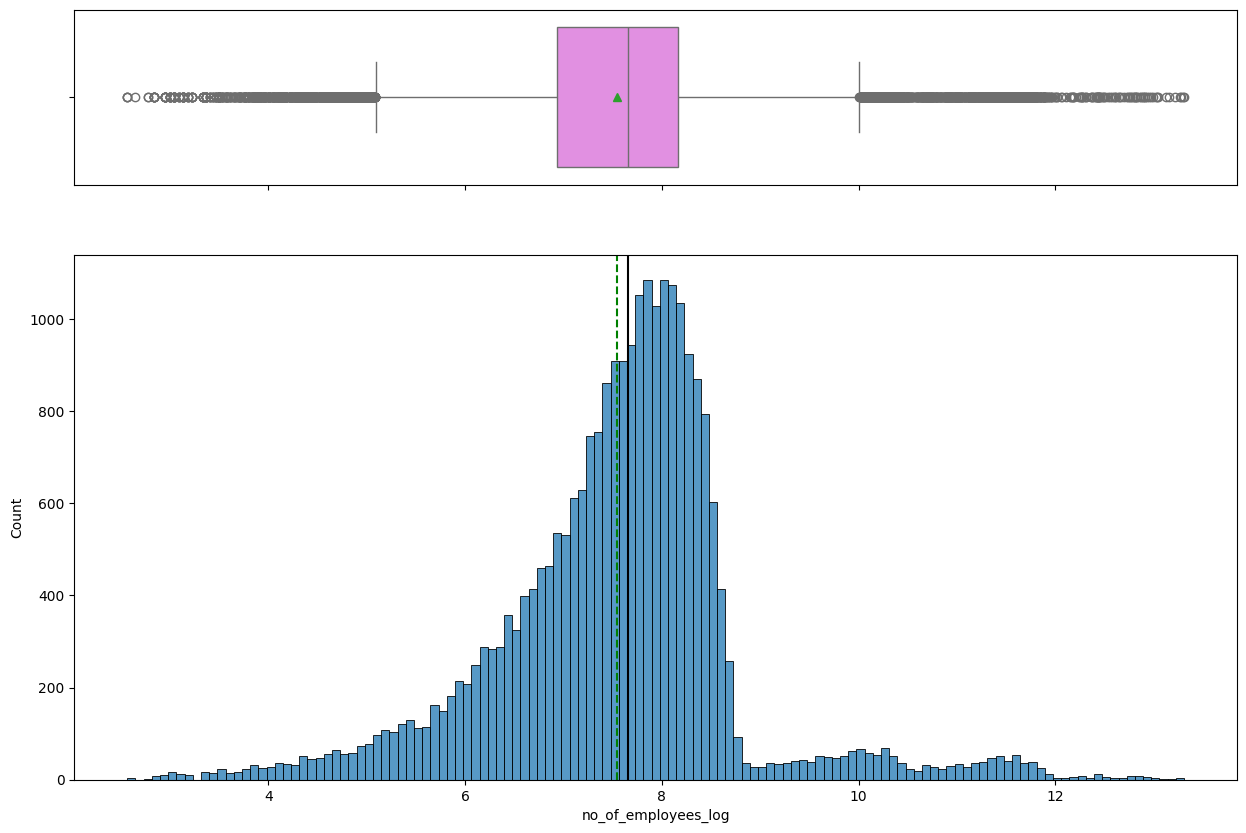

In [ ]:
import numpy as np
data['no_of_employees_log'] = np.log1p(data['no_of_employees'])
histogram_boxplot(data, 'no_of_employees_log', figsize=(15, 10))

Here, I've created a new column `no_of_employees_log` by applying a log transformation (`np.log1p` which computes `log(1+x)` to handle zero values gracefully) to the `no_of_employees` column. As you can see, the boxplot is now much more spread out and readable, and the distribution in the histogram appears less skewed, allowing for a better understanding of the data.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
 12  company_age            25480 non-null  int64  
 13  no_of_employees_log    25447 non-null  float64
dtypes: float64(2), int64(3), object(9)
memory usage: 2.7+ 

## region of employment

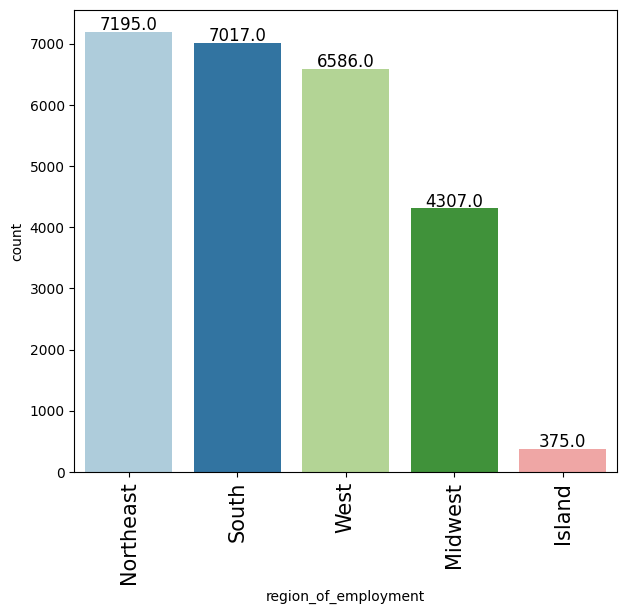

In [ ]:
labeled_barplot(data, "region_of_employment")

## full_time_position

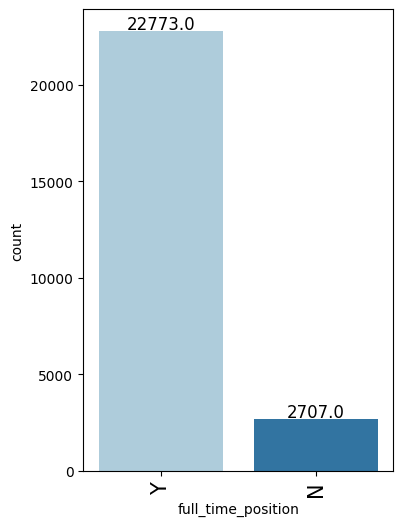

In [ ]:
labeled_barplot(data, "full_time_position")

Observation:
* Full time position heavily influence the visa approval  status.

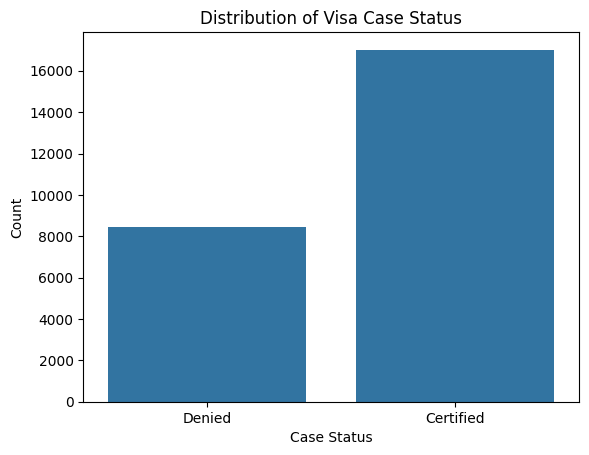

In [ ]:
# Bar plot
plt.figure()
sns.countplot(data=data, x='case_status')
plt.title("Distribution of Visa Case Status")
plt.xlabel("Case Status")
plt.ylabel("Count")
plt.show()

In [ ]:
data.sample(n=10,random_state=15)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age,no_of_employees_log
24978,EZYV24979,Europe,High School,Y,Y,606,2009,South,17958.2900,Year,Y,Denied,17,6.408529
22893,EZYV22894,Asia,Bachelor's,Y,N,1396,2006,West,94110.2300,Year,Y,Denied,20,7.242082
14833,EZYV14834,Asia,Master's,Y,N,1279,2007,Northeast,1221.0800,Year,Y,Certified,19,7.154615
9736,EZYV9737,Asia,Bachelor's,N,N,1627,2011,Northeast,50743.3200,Year,Y,Denied,15,7.395108
20457,EZYV20458,North America,High School,N,N,1403,2013,West,76392.4700,Year,Y,Denied,13,7.247081
8291,EZYV8292,Asia,Master's,N,N,593,1983,Northeast,101002.4600,Year,N,Certified,43,6.386879
14408,EZYV14409,Europe,Master's,N,N,1084,1863,West,15254.3900,Year,Y,Certified,163,6.989335
3356,EZYV3357,Asia,Bachelor's,Y,N,4959,1947,South,73108.4200,Week,Y,Certified,79,8.509161
8787,EZYV8788,Asia,High School,N,N,2565,1885,Midwest,188931.5500,Year,Y,Denied,141,7.850104
4411,EZYV4412,Europe,Bachelor's,N,N,633,2009,Northeast,813.4241,Hour,Y,Certified,17,6.452049


# Bivariate

In [ ]:
data['case_status']=data['case_status'].map({'Denied':0, 'Certified':1})

In [ ]:
data['case_status']

,case_status
0,0
1,1
2,0
3,0
4,1
...,...
25475,1
25476,1
25477,1
25478,1


Data conversion from categorical to numerical

## case status Vs continent

<Axes: xlabel='continent', ylabel='case_status'>

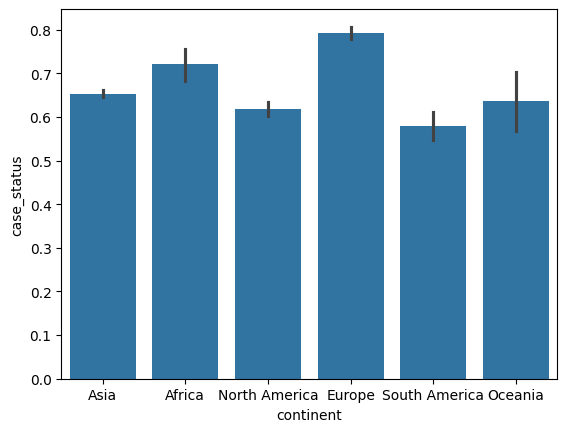

In [ ]:
sns.barplot(data=data, y="case_status", x="continent")

Observation:
* Europe has the highest approval likelihood, followed by Africa and Asia
* South America has the lowest.

## case status Vs education_of_employee

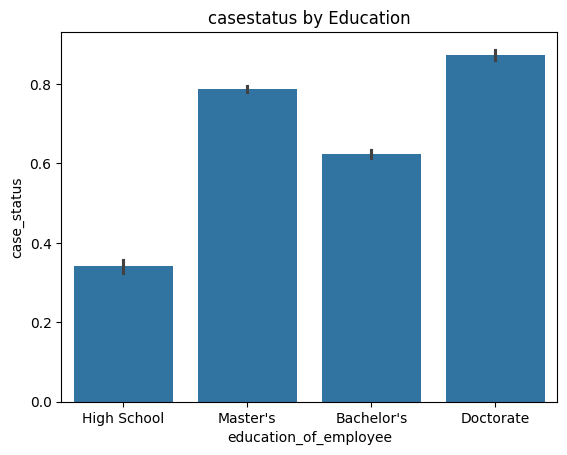

In [ ]:
sns.barplot(data=data, y="case_status", x="education_of_employee")

plt.title("casestatus by Education")
plt.ylabel("case_status")
plt.xlabel("education_of_employee")
plt.show()

Observation

* The Doctorate bar is the tallest, around 0.75–0.80  and most likely to be certified
* The Master’s bar is slightly lower than Doctorate but still high  and also factor that get certified



## case_Status Vs requires_job_training

<Axes: xlabel='requires_job_training', ylabel='case_status'>

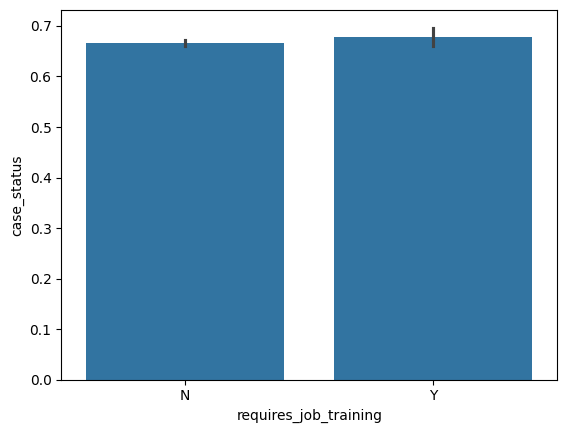

In [ ]:
sns.barplot(data=data, y="case_status", x="requires_job_training")

Observation:


*  Both  certified and denied are balanced for the job training
*  so requires_job_training  does not influence visa approval status



##  case status Vs has_job_experience

<Axes: xlabel='has_job_experience', ylabel='case_status'>

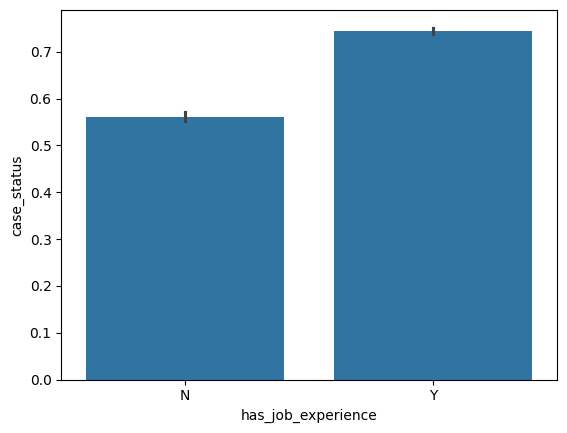

In [ ]:
sns.barplot(data=data, y="case_status", x="has_job_experience")

Observation:
* The bar for Y (has experience) is around 0.73, while the bar for N is around 0.56. So Job experience is a strong positive driver of visa certification.

## casestatus Vs company_age

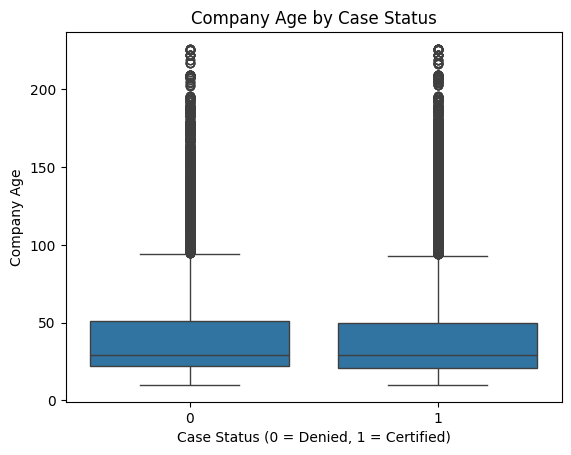

In [ ]:
sns.boxplot(data=data, x='case_status', y='company_age')
plt.title("Company Age by Case Status")
plt.xlabel("Case Status (0 = Denied, 1 = Certified)")
plt.ylabel("Company Age")
plt.show()


Observation:
* Both the Medians are identical
* Distributions are same for both denied and certified



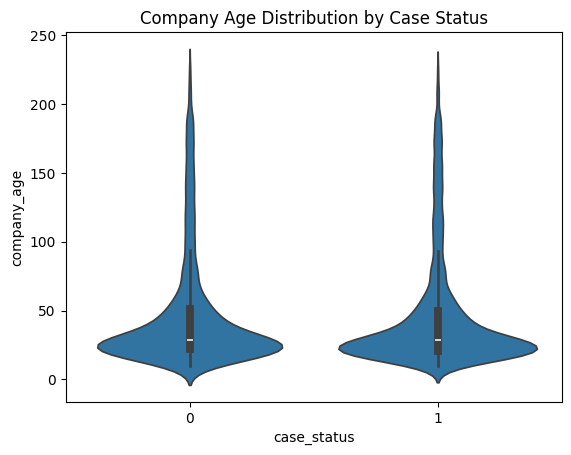

In [ ]:
sns.violinplot(data=data, x='case_status', y='company_age')
plt.title("Company Age Distribution by Case Status")
plt.show()


## casestatus Vs fulltimeposition

<Axes: xlabel='full_time_position', ylabel='case_status'>

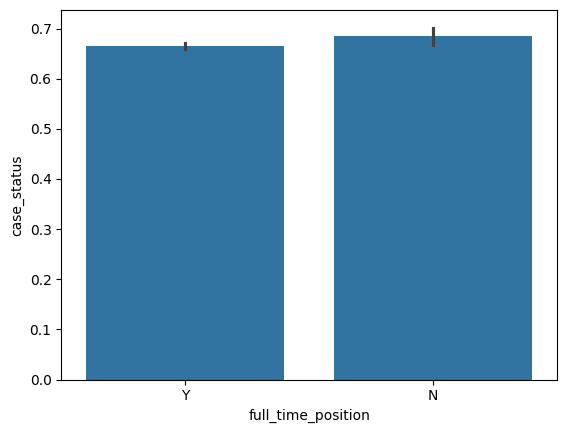

In [ ]:
sns.barplot(data=data, x="full_time_position", y="case_status")

Observation:
* Y → Full time position
* Both bars are around 0.65- 0.70, meaning the average certification rate is similar for both categories.


## case status Vs region_of_employment

<Axes: xlabel='region_of_employment', ylabel='case_status'>

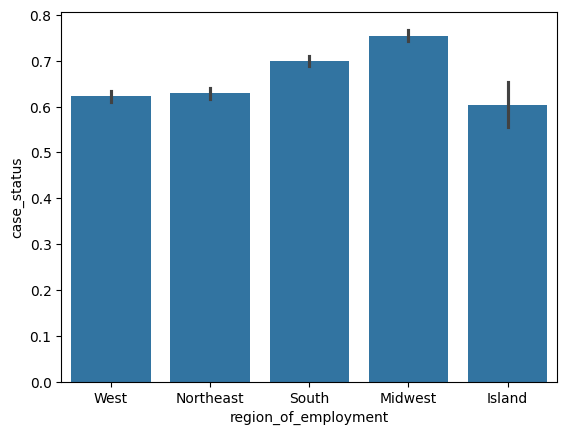

In [ ]:
sns.barplot(data=data, y="case_status", x="region_of_employment")

Observation:
* The Midwest shows the highest approval likelihood, followed by the South and West. The Northeast has moderate certification levels, while the Island region has the lowest.

## case status Vs unit_of_Wage

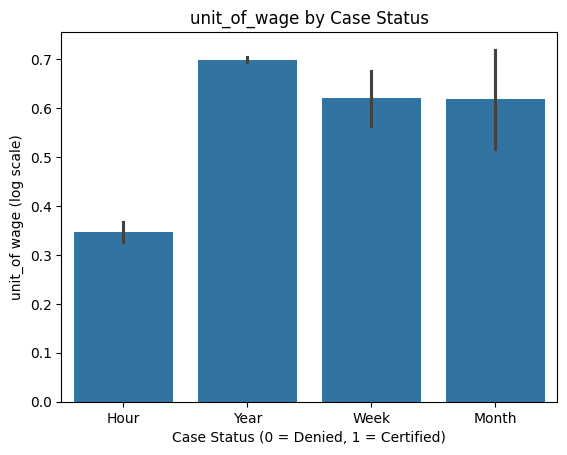

In [ ]:
sns.barplot(data=data, y='case_status', x='unit_of_wage')
plt.title("unit_of_wage by Case Status")
plt.xlabel("Case Status (0 = Denied, 1 = Certified)")
plt.ylabel("unit_of wage (log scale)")
plt.show()


Observation:
Hourly wage shows lowest range and have higher denial rates

## case_status Vs prevailing wage

<Axes: xlabel='case_status', ylabel='prevailing_wage'>

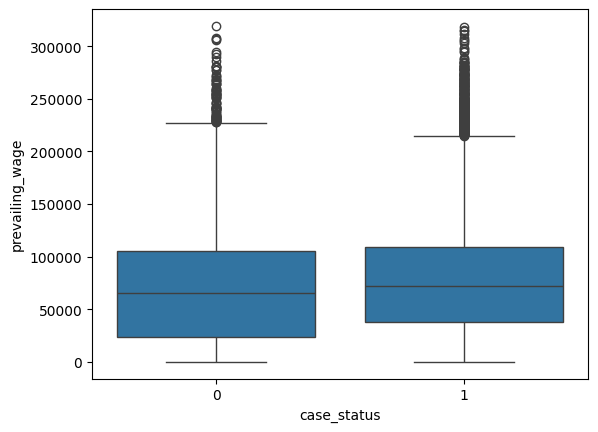

In [ ]:
sns.boxplot(data=data, x='case_status', y='prevailing_wage')

Observation:
Certified cases have a higher median prevailing wage.
Applicants with higher prevailing wages are more likely to be certified.

# Multivariate

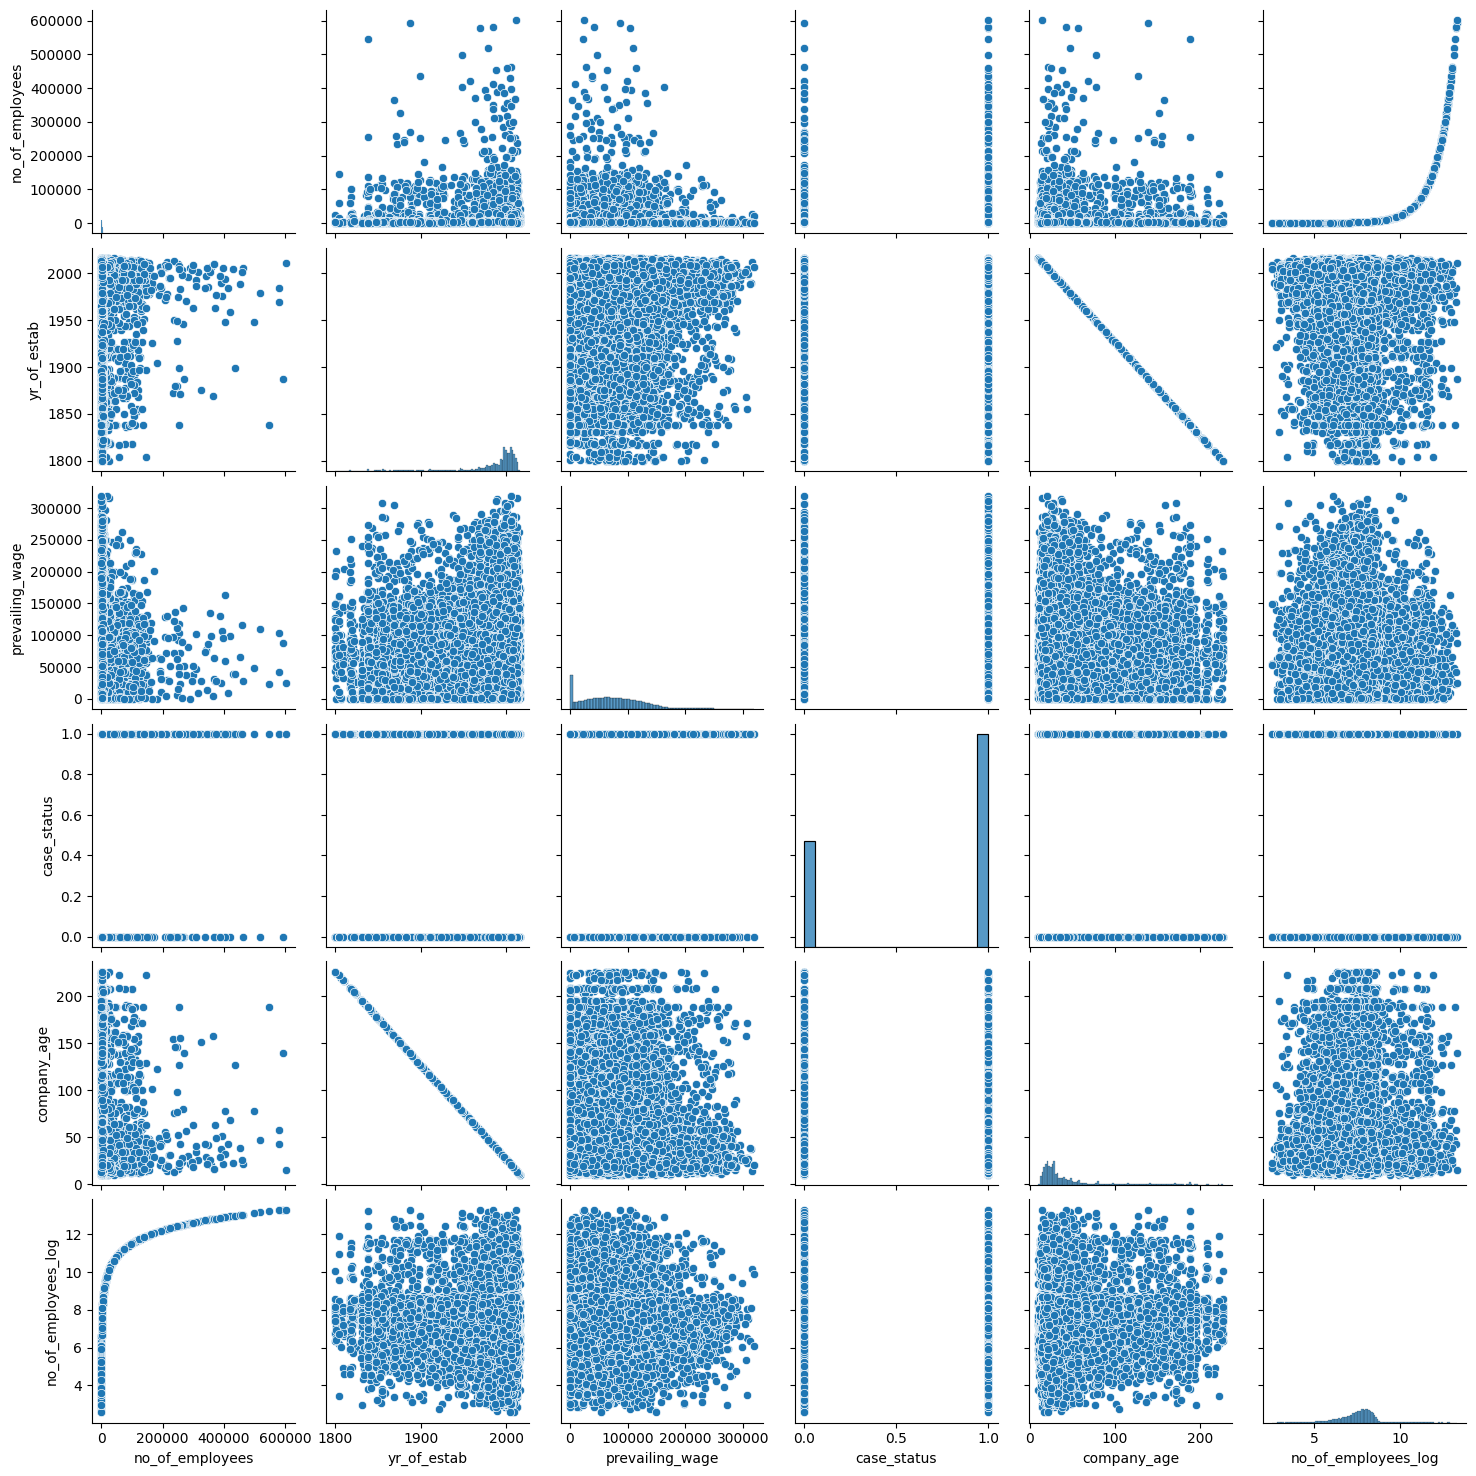

In [ ]:
sns.pairplot(data)

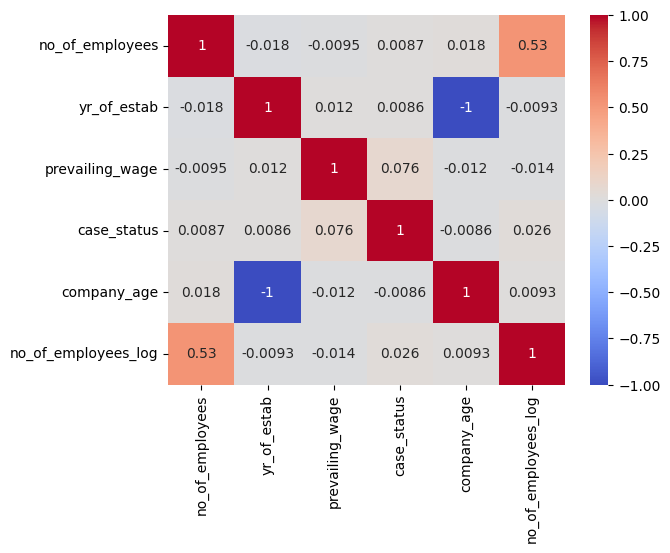

In [ ]:
# plotting the correlation heatmap
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm');

Observatio:
no_of_employees (0.53) is stronger with its log feature.
* All other correlations are close to zero, indicating that visa certification decisions are not driven by simple linear relationships.The data set is suitable for tree-based models.

# **Data Pre-processing**

## drop case_id

In [ ]:
data=data.drop(['case_id','requires_job_training','company_age','full_time_position'], axis=1)

In [ ]:
data.sample(n=2, random_state=12)

,continent,education_of_employee,has_job_experience,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,case_status,no_of_employees_log
16896,Asia,Master's,Y,3005,1985,Midwest,105503.36,Year,1,8.008366
11264,Europe,Master's,N,1260,1977,Northeast,125796.30,Year,1,7.139660


## case_status

In [ ]:
# Counts and percentages
status_counts = data['case_status'].value_counts()
status_pct = data['case_status'].value_counts(normalize=True) * 100
print(status_counts)
print(status_pct)

case_status
1    17018
0     8462
Name: count, dtype: int64
case_status
1    66.789639
0    33.210361
Name: proportion, dtype: float64


Observation:
*  The class weight balance is half between denied and certified.
*  Denied -8462 -33%
*  Certified - 17018 - 67%




## scaling annual_wage- prevailing_wage, unit_of_wage

In [ ]:
# Example conversion to yearly wage (you can adjust factors if needed)
# Conversion factors to annual wage
conversion_factors = {
    'Hour': 40 * 52,     # 40 hours/week * 52 weeks
    'Week': 52,
    'Month': 12,
    'Year': 1
}

# Create annual wage column
data['annual_wage'] = data['prevailing_wage'] * data['unit_of_wage'].map(conversion_factors)

# Drop original columns
data = data.drop(columns=['prevailing_wage', 'unit_of_wage'])

# Scale annual wage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data['annual_wage_scaled'] = scaler.fit_transform(data[['annual_wage']])

# Check result
data[['annual_wage', 'annual_wage_scaled']].head()


,annual_wage,annual_wage_scaled
0,1231782.032,1.787809
1,83425.650,-0.196974
2,122996.860,-0.128581
3,83434.030,-0.196960
4,149907.390,-0.082069


- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

## Label encoder

In [ ]:
data['has_job_experience']=data['has_job_experience'].map({'Y':1,'N':0})

In [ ]:
# @title
# defining the list of numerical features to plot

from sklearn.preprocessing import OrdinalEncoder
cat_cols = ['continent', 'region_of_employment','education_of_employee']
encoder = OrdinalEncoder()
data[cat_cols] = encoder.fit_transform(data[cat_cols])

Observation:All of these wages are below the dataset’s mean annual wage, so their scaled values are negative.

# **Model Building - Original Data**

In [ ]:
#cdefine independnt and target variables
X=data.drop('case_status', axis=1)
y=data['case_status']

# split train test data
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.20, random_state=42)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Split train-test data
X = data.drop(columns=['case_status'])
y = data['case_status']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## 1.Logistic Regression

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- Check for NaNs in X_train (addressing user's question) ---
# print(f"Number of NaN values in X_train: {X_train.isnull().sum().sum()}") # No longer needed, as X_train should be clean after new preprocessing


# Determine numeric and categorical columns from the current X_train for preprocessing
# Note: After previous steps, 'X' (and thus X_train) should be all numeric and NaN-free.
# So, 'cat_cols' will be empty and 'num_cols' will contain all features.
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include='object').columns # This should be an empty Index

# Numeric pipeline (for scaling, imputation for safety though data should be clean)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Redundant if no NaNs, but safe
    ('scaler', StandardScaler())
])

# Categorical pipeline (will not apply if cat_cols is empty)
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Redundant if no NaNs, but safe
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Full preprocessing ColumnTransformer
preprocess = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols) # This will not apply any transformation if cat_cols is empty
])

# --- Define and fit the Logistic Regression pipeline ---
log_reg = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')) # Added random_state for reproducibility and class_weight
])

log_reg.fit(X_train, y_train)
print("Logistic Regression model with class weights fitted successfully!")

Logistic Regression model with class weights fitted successfully!


The 25 NaN values in  X_train dataset are indeed negligible, representing less than 0.1% of your data. The Logistic Regression pipeline will handle these using median imputation, so they won't cause issues during training.

Accuracy: 0.6175824175824176
Precision: 0.7450134770889488
Recall: 0.6497414198401504
F1 Score: 0.694123556002009

Confusion Matrix:
 [[1170  946]
 [1490 2764]]


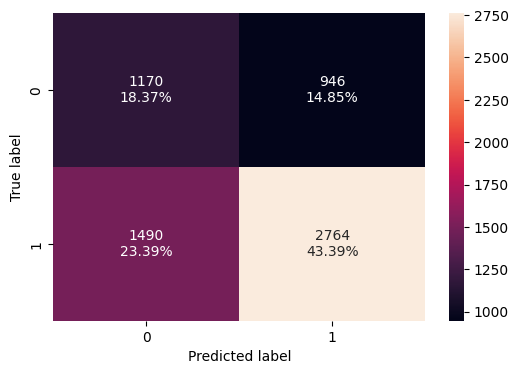

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
confusion_matrix_sklearn(log_reg, X_test, y_test)


## 2.DecisionTree

Decision Trees naturally handle non‑linear relationships and often perform better on imbalanced datasets, making them a logical next model to evaluate.

In [ ]:
nan_rows = X_train[X_train.isnull().any(axis=1)]
display(nan_rows)

,continent,education_of_employee,has_job_experience,no_of_employees,yr_of_estab,region_of_employment,no_of_employees_log,annual_wage,annual_wage_scaled
14726,1.0,3.0,0,-11,2000,1.0,NaN,167851.800,-0.051055
23476,2.0,3.0,1,-11,2000,4.0,NaN,95072.750,-0.176844
245,2.0,3.0,0,-25,1980,2.0,NaN,39452.990,-0.272975
7224,2.0,1.0,0,-25,1998,1.0,NaN,141435.950,-0.096711
21944,0.0,3.0,1,-25,1977,1.0,NaN,79150.510,-0.204363
378,1.0,0.0,0,-11,2011,2.0,NaN,32506.140,-0.284982
16157,1.0,3.0,1,-11,1994,3.0,NaN,62681.250,-0.232828
20984,2.0,1.0,1,-14,1989,1.0,NaN,37012.800,-0.277193
17844,1.0,0.0,0,-14,2012,4.0,NaN,29325.850,-0.290479
6439,1.0,0.0,0,-14,2013,3.0,NaN,216257.600,0.032608


Imputing- Using SimpleImputer NaN values was handled in Data Preprocessing
          Negative values are handled by logorithmic function during data processing through pipeline

**Reasoning**:
Based on the instructions, I need to define a scikit-learn Pipeline for a RandomForestClassifier. This involves identifying numerical columns, defining preprocessing steps with `ColumnTransformer` (including `SimpleImputer` and `StandardScaler`), and then creating the `rf_model` pipeline with the preprocessing and the `RandomForestClassifier` set with `class_weight='balanced'` and `random_state=42`. Since all relevant columns in `X_train` are already numerical due to prior encoding, the categorical pipeline will be effectively empty, but it's included for completeness in the `ColumnTransformer` structure.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

# Re-define preprocess for Decision Tree if needed, but it should be globally defined after data cleaning
# Assuming `preprocess` from Logistic Regression cell is available and updated if needed.

# Ensure num_pipeline and cat_pipeline are defined if not already in the global scope
# (they are defined in the log_reg cell, but if this cell is run independently, they might not be)
# For robustness, include them here as well.
num_pipeline_dt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_dt = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Determine numeric and categorical columns from X_train for preprocessing
num_cols_dt = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols_dt = X_train.select_dtypes(include='object').columns

preprocess_dt = ColumnTransformer(transformers=[
    ('num', num_pipeline_dt, num_cols_dt),
    ('cat', cat_pipeline_dt, cat_cols_dt)
])

# Define and fit the Decision Tree pipeline with class_weight='balanced'
model2 = Pipeline([
    ('prep', preprocess_dt),
    ('model', DecisionTreeClassifier(
        max_depth=None,random_state=1, class_weight='balanced'))
])

model2.fit(X_train, y_train)
print("Decision Tree Classifier with class weights fitted successfully!")

Decision Tree Classifier with class weights fitted successfully!


In [ ]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [ ]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.64898,0.736718,0.737412,0.737065


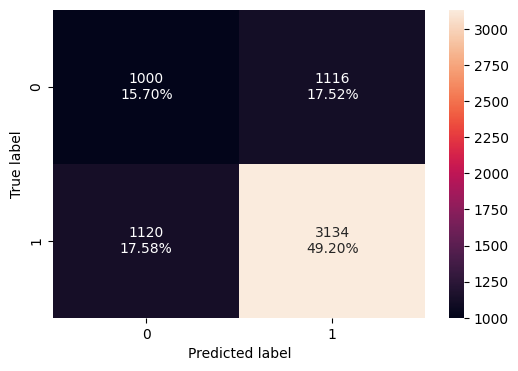

In [ ]:
confusion_matrix_sklearn(model2, X_test, y_test)

The model is overfitting.

## 3.RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns from X_train
# Based on previous steps, all columns in X_train should now be numerical.
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include='object').columns # This should be empty

# Numeric pipeline (for scaling, imputation for safety though data should be clean)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Redundant if no NaNs, but safe
    ('scaler', StandardScaler())
])

# Categorical pipeline (will not apply if cat_cols is empty, but useful for general structure)
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Redundant if no NaNs, but safe
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Full preprocessing ColumnTransformer
preprocess = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols) # This will not apply any transformation if cat_cols is empty
])

# Create the Random Forest Classifier pipeline
rf_model = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

# Fit the Random Forest model to the training data
rf_model.fit(X_train, y_train)
print("Random Forest Classifier with class weights fitted successfully!")

Random Forest Classifier with class weights fitted successfully!


**Reasoning**:
Now that the Random Forest model is fitted, I need to evaluate its performance on the training data using the `model_performance_classification_sklearn` function to get accuracy, recall, precision, and F1-score. This will help assess for overfitting.



In [ ]:
rf_model_train_perf = model_performance_classification_sklearn(rf_model, X_train, y_train)
print("Random Forest Training Performance:")
print(rf_model_train_perf)

Random Forest Training Performance:
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


**Reasoning**:
After evaluating the Random Forest model on the training data, I will now evaluate its performance on the test data using the `model_performance_classification_sklearn` function to see how well it generalizes and to further check for overfitting.



In [ ]:
rf_model_test_perf = model_performance_classification_sklearn(rf_model, X_test, y_test)
print("Random Forest Test Performance:")
print(rf_model_test_perf)



Random Forest Test Performance:
   Accuracy    Recall  Precision       F1
0  0.708948  0.835214   0.754994  0.79308


**Reasoning**:
To visually inspect the performance of the Random Forest Classifier on the test set and identify true positives, true negatives, false positives, and false negatives, I will plot its confusion matrix.



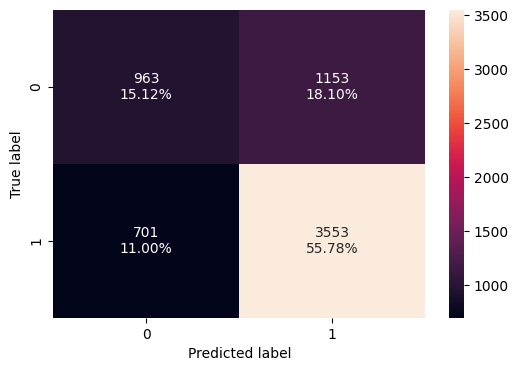

In [ ]:
confusion_matrix_sklearn(rf_model, X_test, y_test)

## 4.BaggingClassifier

In [ ]:
bg_model = Pipeline([
    ('prep', preprocess),
    ('model', BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200,
        max_samples=0.8,
        max_features=1.0,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

bg_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['continent', 'education_of_employee', 'has_job_experience',
       'no_of_employees', 'yr_of_estab', 'region_of_employment',
       'no_of_employees_log', 'annual_wage', 'annual_wage_scaled'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model',
                 BaggingClassifier(estimator=DecisionTreeClassifier(),
                                   max_samples=0.8, n_estimators=200, n_jobs=-1,
                                   random_state=42))])

Evaluation metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred_bg = bg_model.predict(X_test)

bg_accuracy = accuracy_score(y_test, y_pred_bg)
bg_precision = precision_score(y_test, y_pred_bg)
bg_recall = recall_score(y_test, y_pred_bg)
bg_f1 = f1_score(y_test, y_pred_bg)

print("Accuracy:", bg_accuracy)
print("Precision:", bg_precision)
print("Recall:", bg_recall)
print("F1 Score:", bg_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_bg))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bg))


Accuracy: 0.7131868131868132
Precision: 0.7634035163881051
Recall: 0.8267512929007993
F1 Score: 0.793815596433811

Confusion Matrix:
 [[1026 1090]
 [ 737 3517]]


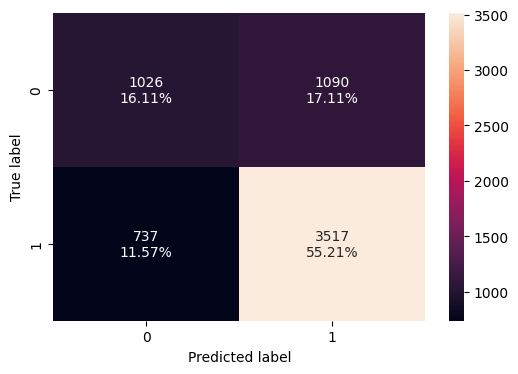

In [ ]:
confusion_matrix_sklearn(bg_model, X_test, y_test)

Feature Importance

In [ ]:
# Extract feature names
feature_names_bg = (
    list(num_cols)
)

# Average feature importances across all trees
import numpy as np

tree_importances = np.array([
    tree.feature_importances_ for tree in bg_model.named_steps['model'].estimators_
])

avg_importances = np.mean(tree_importances, axis=0)

fi_bg = pd.DataFrame({
    'Feature': feature_names_bg,
    'Importance': avg_importances
}).sort_values(by='Importance', ascending=False)

fi_bg.head(20)

,Feature,Importance
4,yr_of_estab,0.176810
8,annual_wage_scaled,0.151686
7,annual_wage,0.149682
3,no_of_employees,0.135239
6,no_of_employees_log,0.134337
1,education_of_employee,0.111033
5,region_of_employment,0.049408
0,continent,0.046592
2,has_job_experience,0.045213





* education_of_employee, has_job_Experience, no_of_employees, region_of _employment are the strong predictors for the visa approval

*  Matches EDA - Education, wage, experience, region were already strong predictors.

## 5.Gradient Boosting Classifier

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Numeric pipeline
num_pipeline_gb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
cat_pipeline_gb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Full preprocessing
preprocess_gb = ColumnTransformer([
    ('num', num_pipeline_gb, num_cols),
    ('cat', cat_pipeline_gb, cat_cols)
])


Model training

In [ ]:
gb_model = Pipeline([
    ('prep', preprocess_gb),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])
gb_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['continent', 'education_of_employee', 'has_job_experience',
       'no_of_employees', 'yr_of_estab', 'region_of_employment',
       'no_of_employees_log', 'annual_wage', 'annual_wage_scaled'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
y_pred_gb = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


Accuracy: 0.7357927786499215
Precision: 0.7686520376175549
Recall: 0.8645980253878702
F1 Score: 0.8138068370394955

Confusion Matrix:
 [[1009 1107]
 [ 576 3678]]


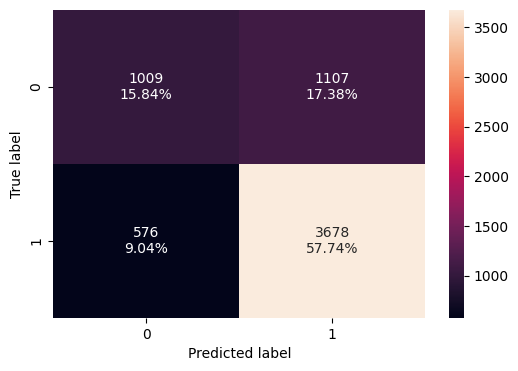

In [ ]:
confusion_matrix_sklearn(gb_model, X_test, y_test)

**Reasoning**:
I need to append the Gradient Boosting model's performance metrics to the `results` DataFrame. I will create a dictionary with the model name and its metrics and then use `pd.concat` to add it as a new row to the existing `results` DataFrame.



## Feature Importance

In [ ]:
feature_names_gb = (


    list(num_cols)
)
importances_gb = gb_model.named_steps['model'].feature_importances_
fi_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False)
fi_gb.head(20)


,Feature,Importance
1,education_of_employee,0.445747
2,has_job_experience,0.166077
0,continent,0.109741
7,annual_wage,0.077777
8,annual_wage_scaled,0.073823
5,region_of_employment,0.064967
4,yr_of_estab,0.022216
3,no_of_employees,0.022088
6,no_of_employees_log,0.017564


In [ ]:
gb_metrics = {
    'Model': 'Gradient Boosting Classifier',
    'Accuracy': gb_accuracy,
    'Precision': gb_precision,
    'Recall': gb_recall,
    'F1 Score': gb_f1
}

# Initialize results DataFrame if it doesn't exist, or ensure it's defined earlier
if 'results' not in locals():
    results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

results = pd.concat([results, pd.DataFrame([gb_metrics])], ignore_index=True)
print("Gradient Boosting Classifier metrics added to results DataFrame.")
results

Gradient Boosting Classifier metrics added to results DataFrame.


,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
1,Decision Tree (Oversampled),0.647253,0.735287,0.737189,0.736237
2,Gradient Boosting (Oversampled),0.701099,0.814507,0.715327,0.761702
3,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288
4,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
5,Decision Tree (Undersampled),0.611774,0.758491,0.614245,0.678789
6,XGBoost (Original Data),0.704082,0.811957,0.724730,0.765868
7,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
8,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
9,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288


# **Model Building - Oversampled Data**

### **Oversampling with RandomOverSampler**

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply the preprocessing pipeline to X_train and X_test
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

# Apply RandomOverSampler to the processed training data
X_train_ros, y_train_ros = ros.fit_resample(X_train_processed, y_train)

print(f"Shape of X_train before ROS: {X_train_processed.shape}")
print(f"Shape of X_train after ROS: {X_train_ros.shape}")
print(f"Class distribution of y_train before ROS:\n{y_train.value_counts()}")
print(f"Class distribution of y_train after ROS:\n{y_train_ros.value_counts()}")

Shape of X_train before ROS: (19110, 9)
Shape of X_train after ROS: (25528, 9)
Class distribution of y_train before ROS:
case_status
1    12764
0     6346
Name: count, dtype: int64
Class distribution of y_train after ROS:
case_status
1    12764
0    12764
Name: count, dtype: int64





* By over sampling, now  the class weight is balanced between denied and certified
* After over sampling the sam[ples are increase from 19110 to 25528



### Logistic Regression with RandomOverSampler



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Initialize Logistic Regression model with class_weight='balanced' (or let ROS handle balance)
# Since we've oversampled, we don't necessarily need class_weight here, but it can be used for safety.
log_reg_ros = LogisticRegression(max_iter=500, random_state=42)

# Train the model on the RandomOverSampled data
log_reg_ros.fit(X_train_ros, y_train_ros)

# Predict on the preprocessed test data
y_pred_log_ros = log_reg_ros.predict(X_test_processed)

# Evaluate the model
accuracy_ros = accuracy_score(y_test, y_pred_log_ros)
precision_ros = precision_score(y_test, y_pred_log_ros)
recall_ros = recall_score(y_test, y_pred_log_ros)
f1_ros = f1_score(y_test, y_pred_log_ros)

print("--- Logistic Regression with RandomOverSampler ---")
print("Accuracy:", accuracy_ros)
print("Precision:", precision_ros)
print("Recall:", recall_ros)
print("F1 Score:", f1_ros)

# print("\nClassification Report:\n", classification_report(y_test, y_pred_log_ros))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_ros))
print("X_train after oversampling", X_train_ros.shape[0])
print("y_train after oversampling", y_train_ros.shape[0])
print("X_train before oversampling", X_train.shape[0])
print("y_train before oversampling", y_train.shape[0])

results.loc[len(results)] = [
    'Logistic regression (over sampled)',
    accuracy_ros,
    precision_ros,
    recall_ros,
    f1_ros
]


--- Logistic Regression with RandomOverSampler ---
Accuracy: 0.6177394034536892
Precision: 0.7450821880894638
Recall: 0.6499764927127409
F1 Score: 0.6942875078468299

Confusion Matrix:
 [[1170  946]
 [1489 2765]]
X_train after oversampling 25528
y_train after oversampling 25528
X_train before oversampling 19110
y_train before oversampling 19110


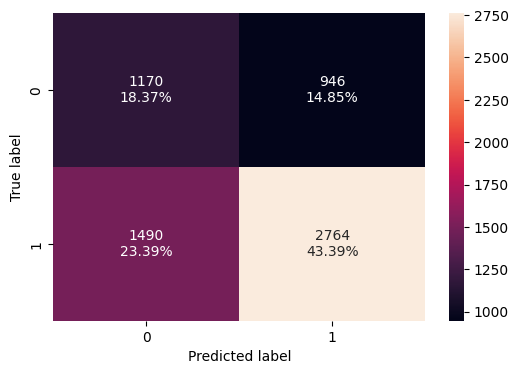

In [ ]:
confusion_matrix_sklearn(log_reg, X_test, y_test)

### DecisionTree

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

dt_over = Pipeline([
    ('prep', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_over.fit(X_train_over, y_train_over)
y_pred_dt_over = dt_over.predict(X_test)

# Evaluation
dt_over_accuracy = accuracy_score(y_test, y_pred_dt_over)
dt_over_precision = precision_score(y_test, y_pred_dt_over)
dt_over_recall = recall_score(y_test, y_pred_dt_over)
dt_over_f1 = f1_score(y_test, y_pred_dt_over)

print("Accuracy:", dt_over_accuracy)
print("Precision:", dt_over_precision)
print("Recall:", dt_over_recall)
print("F1 Score:", dt_over_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_over))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_over))

# update results table
results.loc[len(results)] = [
    'Decision Tree (Oversampled)',
    dt_over_accuracy,
    dt_over_precision,
    dt_over_recall,
    dt_over_f1
    ]

print("X_train after oversampling", X_train_over.shape[0])
print("y_train after oversampling", y_train_over.shape[0])
print("X_train before oversampling", X_train.shape[0])
print("y_train before oversampling", y_train.shape[0])


Accuracy: 0.6472527472527473
Precision: 0.7352872215709262
Recall: 0.7371885284438175
F1 Score: 0.7362366474938373

Confusion Matrix:
 [[ 987 1129]
 [1118 3136]]
X_train after oversampling 25528
y_train after oversampling 25528
X_train before oversampling 19110
y_train before oversampling 19110


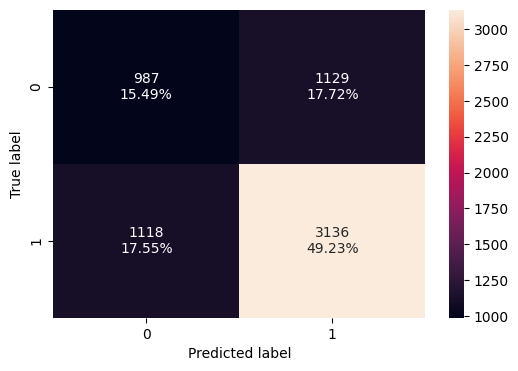

In [ ]:
confusion_matrix_sklearn(dt_over, X_test, y_test)

### Random Forest

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

rf_over = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_over.fit(X_train_over, y_train_over)
y_pred_rf_over = rf_over.predict(X_test)

# Evaluation
rf_over_accuracy = accuracy_score(y_test, y_pred_rf_over)
rf_over_precision = precision_score(y_test, y_pred_rf_over)
rf_over_recall = recall_score(y_test, y_pred_rf_over)
rf_over_f1 = f1_score(y_test, y_pred_rf_over)

# Results
print("Accuracy:", rf_over_accuracy)
print("Precision:", rf_over_precision)
print("Recall:", rf_over_recall)
print("F1 Score:", rf_over_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_over))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_over))

# update results table
results.loc[len(results)] = [
    'DRandom Forest (Oversampled)',
    rf_over_accuracy,
    rf_over_precision,
    rf_over_recall,
    rf_over_f1
    ]


Accuracy: 0.7026687598116169
Precision: 0.7727693018955155
Recall: 0.7858486130700517
F1 Score: 0.7792540792540793

Confusion Matrix:
 [[1133  983]
 [ 911 3343]]


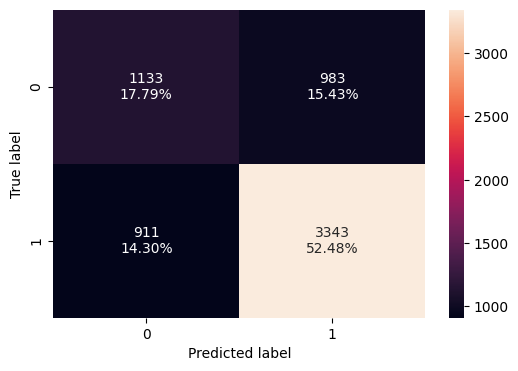

In [ ]:
confusion_matrix_sklearn(rf_over, X_test, y_test)

### BaggingClassifier

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

bg_over = Pipeline([
    ('prep', preprocess),
    ('model', BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

bg_over.fit(X_train_over, y_train_over)
y_pred_bg_over = bg_over.predict(X_test)


bg_over_accuracy = accuracy_score(y_test, y_pred_bg_over)
bg_over_precision = precision_score(y_test, y_pred_bg_over)
bg_over_recall = recall_score(y_test, y_pred_bg_over)
bg_over_f1 = f1_score(y_test, y_pred_bg_over)

print("Accuracy:", bg_over_accuracy)
print("Precision:", bg_over_precision)
print("Recall:", bg_over_recall)
print("F1 Score:", bg_over_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_bg_over))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bg_over))

print("X_train after oversampling", X_train_over.shape[0])
print("y_train after oversampling", y_train_over.shape[0])
print("X_train before oversampling", X_train.shape[0])
print("y_train before oversampling", y_train.shape[0])

# update results table
results.loc[len(results)] = [
    'Bagging Classifier (Oversampled)',
    bg_over_accuracy,
    bg_over_precision,
    bg_over_recall,
    bg_over_f1
    ]


Accuracy: 0.6910518053375196
Precision: 0.7693213949104618
Recall: 0.7675129290079925
F1 Score: 0.7684160979053895

Confusion Matrix:
 [[1137  979]
 [ 989 3265]]
X_train after oversampling 25528
y_train after oversampling 25528
X_train before oversampling 19110
y_train before oversampling 19110


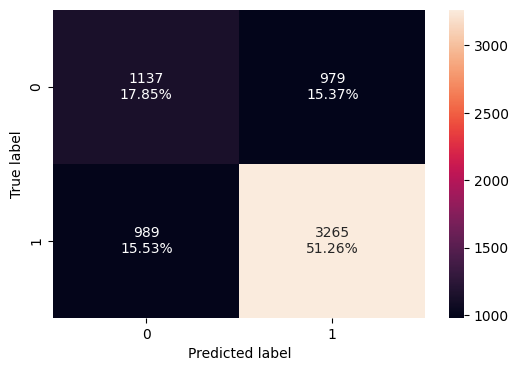

In [ ]:
confusion_matrix_sklearn(bg_over, X_test, y_test)

### Gradient Boosting

In [ ]:

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

gb_over = Pipeline([
    ('prep', preprocess_gb),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_over.fit(X_train_over, y_train_over)
y_pred_gb_over = gb_over.predict(X_test)


gb_over_accuracy = accuracy_score(y_test, y_pred_gb_over)
gb_over_precision = precision_score(y_test, y_pred_gb_over)
gb_over_recall = recall_score(y_test, y_pred_gb_over)
gb_over_f1 = f1_score(y_test, y_pred_gb_over)

print("Accuracy:", gb_over_accuracy)
print("Precision:", gb_over_precision)
print("Recall:", gb_over_recall)
print("F1 Score:", gb_over_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_gb_over))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb_over))

results.loc[len(results)] = [
    'Gradient Boosting (Oversampled)',
    gb_over_accuracy,
    gb_over_precision,
    gb_over_recall,
    gb_over_f1
]

Accuracy: 0.701098901098901
Precision: 0.8145074946466809
Recall: 0.7153267512929008
F1 Score: 0.7617021276595745

Confusion Matrix:
 [[1423  693]
 [1211 3043]]


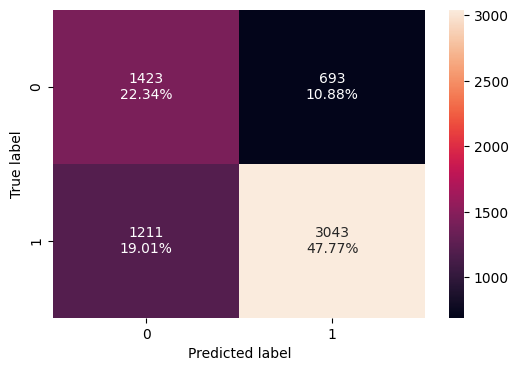

In [ ]:
confusion_matrix_sklearn(gb_over, X_test, y_test)

## comparison table for over sampling

In [ ]:
# Add  metrics to the results DataFrame
ros_log_reg_metrics = {
    'Model': 'Logistic Regression (ROS)',
    'Accuracy': accuracy_ros,
    'Precision': precision_ros,
    'Recall': recall_ros,
    'F1 Score': f1_ros
}
results = pd.concat([results, pd.DataFrame([ros_log_reg_metrics])], ignore_index=True)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
1,Decision Tree (Oversampled),0.647253,0.735287,0.737189,0.736237
2,Gradient Boosting (Oversampled),0.701099,0.814507,0.715327,0.761702
3,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288
4,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
5,Decision Tree (Undersampled),0.611774,0.758491,0.614245,0.678789
6,XGBoost (Original Data),0.704082,0.811957,0.724730,0.765868
7,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
8,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
9,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288


# **Model Building - Undersampled Data**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("X_train after undersampling", X_train_under.shape[0])
print("y_train after undersampling", y_train_under.shape[0])
print("X_train before undersampling", X_train.shape[0])
print("y_train before undersampling", y_train.shape[0])


X_train after undersampling 12692
y_train after undersampling 12692
X_train before undersampling 19110
y_train before undersampling 19110


After under sampling the samples get reduced from 19110 to 12692

### Logistic Regression

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_over, y_train_over = rus.fit_resample(X_train, y_train)
lr_under = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=500))
])

lr_under.fit(X_train_under, y_train_under)
y_pred_lr_under = lr_under.predict(X_test)
# Evaluation
lr_under_accuracy = accuracy_score(y_test, y_pred_lr_under)
lr_under_precision = precision_score(y_test, y_pred_lr_under)
lr_under_recall = recall_score(y_test, y_pred_lr_under)
lr_under_f1 = f1_score(y_test, y_pred_lr_under)

print("Accuracy:", lr_under_accuracy)
print("Precision:", lr_under_precision)
print("Recall:", lr_under_recall)
print("F1 Score:", lr_under_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_under))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_under))

results.loc[len(results)] = [
    'Logistic Regression (Undersampled)',
    lr_under_accuracy,
    lr_under_precision,
    lr_under_recall,
    lr_under_f1
]


Accuracy: 0.6167974882260596
Precision: 0.7445373617480442
Recall: 0.6488011283497884
F1 Score: 0.6933802286144957

Confusion Matrix:
 [[1169  947]
 [1494 2760]]


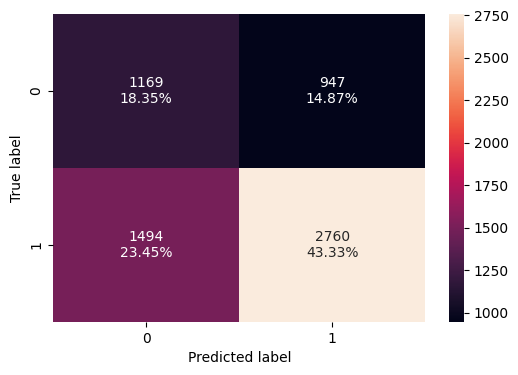

In [ ]:
confusion_matrix_sklearn(lr_under, X_test, y_test)

### Decision Tree

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_over, y_train_over = rus.fit_resample(X_train, y_train)

dt_under = Pipeline([
    ('prep', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_under.fit(X_train_under, y_train_under)
y_pred_dt_under = dt_under.predict(X_test)

dt_under_accuracy = accuracy_score(y_test, y_pred_dt_under)
dt_under_precision = precision_score(y_test, y_pred_dt_under)
dt_under_recall = recall_score(y_test, y_pred_dt_under)
dt_under_f1 = f1_score(y_test, y_pred_dt_under)

print("Accuracy:", dt_under_accuracy)
print("Precision:", dt_under_precision)
print("Recall:", dt_under_recall)
print("F1 Score:", dt_under_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_under))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_under))

results.loc[len(results)] = [
    'Decision Tree (Undersampled)',
    dt_under_accuracy,
    dt_under_precision,
    dt_under_recall,
    dt_under_f1
]


Accuracy: 0.6117739403453689
Precision: 0.7584905660377359
Recall: 0.6142454160789845
F1 Score: 0.6787894531757371

Confusion Matrix:
 [[1284  832]
 [1641 2613]]


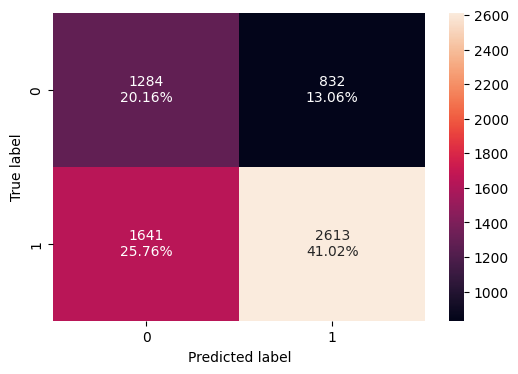

In [ ]:
confusion_matrix_sklearn(dt_under, X_test, y_test)

### Random Forest

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_over, y_train_over = rus.fit_resample(X_train, y_train)

rf_under = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_under.fit(X_train_under, y_train_under)
y_pred_rf_under = rf_under.predict(X_test)

rf_under_accuracy = accuracy_score(y_test, y_pred_rf_under)
rf_under_precision = precision_score(y_test, y_pred_rf_under)
rf_under_recall = recall_score(y_test, y_pred_rf_under)
rf_under_f1 = f1_score(y_test, y_pred_rf_under)

print("Accuracy:", rf_under_accuracy)
print("Precision:", rf_under_precision)
print("Recall:", rf_under_recall)
print("F1 Score:", rf_under_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_under))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_under))

results.loc[len(results)] = [
    'RandomForest (undersampled)',
    rf_under_accuracy,
    rf_under_precision,
    rf_under_recall,
    rf_under_f1
]

Accuracy: 0.6695447409733124
Precision: 0.8076152304609219
Recall: 0.6631405735778091
F1 Score: 0.7282819155802246

Confusion Matrix:
 [[1444  672]
 [1433 2821]]


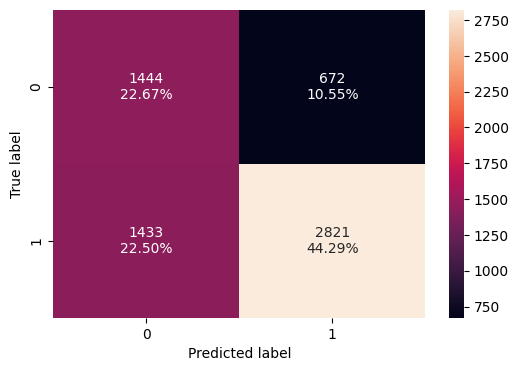

In [ ]:
confusion_matrix_sklearn(rf_under, X_test, y_test)

### BaggingClassifier



In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_over, y_train_over = rus.fit_resample(X_train, y_train)

bg_under = Pipeline([
    ('prep', preprocess),
    ('model', BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

bg_under.fit(X_train_under, y_train_under)
y_pred_bg_under = bg_under.predict(X_test)

#Evaluation
bg_under_accuracy = accuracy_score(y_test, y_pred_bg_under)
bg_under_precision = precision_score(y_test, y_pred_bg_under)
bg_under_recall = recall_score(y_test, y_pred_bg_under)
bg_under_f1 = f1_score(y_test, y_pred_bg_under)

print("Accuracy:", bg_under_accuracy)
print("Precision:", bg_under_precision)
print("Recall:", bg_under_recall)
print("F1 Score:", bg_under_f1)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_bg_under))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bg_under))

results.loc[len(results)] = [
    'Bagging Classifier (undersampled)',
    bg_under_accuracy,
    bg_under_precision,
    bg_under_recall,
    bg_under_f1
]

Accuracy: 0.66436420722135
Precision: 0.8036739380022963
Recall: 0.6582040432534085
F1 Score: 0.7237012147841819

Confusion Matrix:
 [[1432  684]
 [1454 2800]]


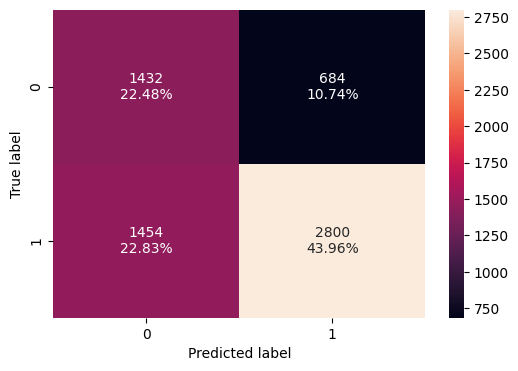

In [ ]:
confusion_matrix_sklearn(bg_under, X_test, y_test)

### Gradient Boosting

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_over, y_train_over = rus.fit_resample(X_train, y_train)

gb_under = Pipeline([
    ('prep', preprocess),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_under.fit(X_train_under, y_train_under)
y_pred_gb_under = gb_under.predict(X_test)

gb_under_accuracy = accuracy_score(y_test, y_pred_gb_under)
gb_under_precision = precision_score(y_test, y_pred_gb_under)
gb_under_recall = recall_score(y_test, y_pred_gb_under)
gb_under_f1 = f1_score(y_test, y_pred_gb_under)

print("Accuracy:", gb_under_accuracy)
print("Precision:", gb_under_precision)
print("Recall:", gb_under_recall)
print("F1 Score:", gb_under_f1)
#print("\nClassification Report:\n", classification_report(y_test, y_pred_gb_under))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb_under))

results.loc[len(results)] = [
    'Gradient Boosting (undersampled)',
    gb_under_accuracy,
    gb_under_precision,
    gb_under_recall,
    gb_under_f1
]

Accuracy: 0.6992150706436421
Precision: 0.8183551198257081
Recall: 0.7063939821344617
F1 Score: 0.7582639414584911

Confusion Matrix:
 [[1449  667]
 [1249 3005]]


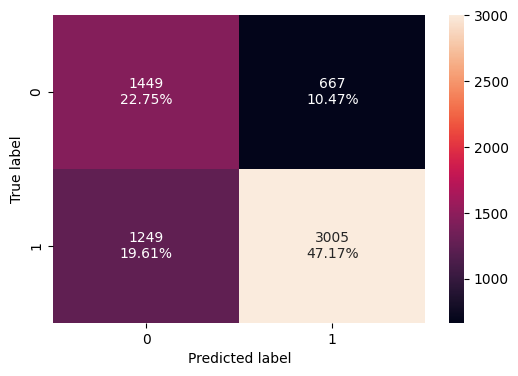

In [ ]:
confusion_matrix_sklearn(gb_under, X_test, y_test)

## Comparison table for 15 models

In [ ]:
metrics = {
    'Model': 'All',
    'Accuracy': gb_accuracy,
    'Precision': gb_precision,
    'Recall': gb_recall,
    'F1 Score': gb_f1
}

# Initialize results DataFrame if it doesn't exist, or ensure it's defined earlier
if 'results' not in locals():
    results = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

results = pd.concat([results, pd.DataFrame([metrics])], ignore_index=True)
print(" metrics added to results DataFrame.")
results

 metrics added to results DataFrame.


,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
1,Decision Tree (Oversampled),0.647253,0.735287,0.737189,0.736237
2,Gradient Boosting (Oversampled),0.701099,0.814507,0.715327,0.761702
3,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288
4,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
5,Decision Tree (Undersampled),0.611774,0.758491,0.614245,0.678789
6,XGBoost (Original Data),0.704082,0.811957,0.724730,0.765868
7,Logistic Regression (Undersampled),0.616797,0.744537,0.648801,0.693380
8,Gradient Boosting Classifier,0.735793,0.768652,0.864598,0.813807
9,Logistic Regression (ROS),0.617739,0.745082,0.649976,0.694288


# **Hyperparameter Tuning**

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# Parameter grid (corrected)
param_grid = {
    "model__n_estimators": [150, 250],
    "model__min_samples_leaf": np.arange(1, 2),
    "model__max_features": [0.4, 'sqrt'],
    "model__max_samples": [0.7,1.0]
}

# Pipeline
rf_pipeline = Pipeline([
    ('prep', preprocess),   # your preprocessing block
    ('model', RandomForestClassifier(random_state=42))
])

# Grid Search
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='recall',      # primary metric
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit
rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Recall:", rf_grid.best_score_)

# Best model
rf_best = rf_grid.best_estimator_

# Evaluate on test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_rf = rf_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test Precision:", precision_score(y_test, y_pred_rf))
print("Test Recall:", recall_score(y_test, y_pred_rf))
print("Test F1:", f1_score(y_test, y_pred_rf))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'model__max_features': 0.4, 'model__max_samples': 0.7, 'model__min_samples_leaf': np.int64(1), 'model__n_estimators': 250}
Best CV Recall: 0.8473041202114606
Test Accuracy: 0.7185243328100471
Test Precision: 0.7615302869287992
Test Recall: 0.8422661024917725
Test F1: 0.7998660564795178


* Fitting 3 folds for each of 8 candidates, totalling 24 fits
* Best Parameters: {'model__max_features': 0.4, 'model__max_samples': 0.7, 'model__min_samples_leaf': np.int64(1), 'model__n_estimators': 250}
* Best CV Recall: 0.8473041202114606
* Test Accuracy: 0.7185243328100471
* Test Precision: 0.7615302869287992
* Test Recall: 0.8422661024917725
* Test F1: 0.7998660564795178

## Bagging Classifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Your parameter grid
param_grid = {
    'model__max_samples': [0.8, 0.9, 1],
    'model__max_features': [0.7, 0.8, 0.9],
    'model__n_estimators': [30, 50, 70]
}

# Pipeline
bag_pipeline = Pipeline([
    ('prep', preprocess),   # your preprocessing block
    ('model', BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        random_state=42
    ))
])

# Grid Search
bag_grid = GridSearchCV(
    estimator=bag_pipeline,
    param_grid=param_grid,
    scoring='recall',      # primary metric
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit
bag_grid.fit(X_train, y_train)

print("Best Parameters:", bag_grid.best_params_)
print("Best CV Recall:", bag_grid.best_score_)

# Best model
bag_best = bag_grid.best_estimator_

# Evaluate on test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_bag = bag_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Test Precision:", precision_score(y_test, y_pred_bag))
print("Test Recall:", recall_score(y_test, y_pred_bag))
print("Test F1:", f1_score(y_test, y_pred_bag))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'model__max_features': 0.7, 'model__max_samples': 1, 'model__n_estimators': 30}
Best CV Recall: 1.0
Test Accuracy: 0.667817896389325
Test Precision: 0.667817896389325
Test Recall: 1.0
Test F1: 0.8008283132530121


* Fitting 3 folds for each of 27 candidates, totalling 81 fits
* Best Parameters: {'model__max_features': 0.7, 'model__max_samples': 1, 'model__n_estimators': 30}
* Best CV Recall: 1.0
* Test Accuracy: 0.667817896389325
* Test Precision: 0.667817896389325
* Test Recall: 1.0
* Test F1: 0.8008283132530121

## Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# Your parameter grid
param_grid = {
    "model__n_estimators": np.arange(100,150,25),
    "model__learning_rate": [0.2, 0.05, 1],
    "model__subsample":[0.5,0.7],
    "model__max_features":[0.5,0.7]
}

# Pipeline
gb_pipeline = Pipeline([
    ('prep', preprocess),   # your preprocessing block
    ('model', GradientBoostingClassifier(random_state=42))
])

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring='recall',      # primary metric
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit
gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Recall:", gb_grid.best_score_)

# Best model
gb_best = gb_grid.best_estimator_

# Evaluate on test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_gb = gb_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Test Precision:", precision_score(y_test, y_pred_gb))
print("Test Recall:", recall_score(y_test, y_pred_gb))
print("Test F1:", f1_score(y_test, y_pred_gb))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_features': 0.5, 'model__n_estimators': np.int64(100), 'model__subsample': 0.5}
Best CV Recall: 0.9044962728104937
Test Accuracy: 0.7270015698587127
Test Precision: 0.7471015916683041
Test Recall: 0.8937470615890927
Test F1: 0.8138713475329123


* Fitting 3 folds for each of 24 candidates, totalling 72 fits
* Best Parameters: {'model__learning_rate': 0.05, 'model__max_features': 0.5, 'model__n_estimators': np.int64(100), 'model__subsample': 0.5}
* Best CV Recall: 0.9044962728104937
* Test Accuracy: 0.7270015698587127
* Test Precision: 0.7471015916683041
* Test Recall: 0.8937470615890927
* Test F1: 0.8138713475329123

# Model Comparison(Random Forest, Bagging classsifier, Gradient Boosting)

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Gradient Boosting (Tuned)",
        "Random Forest (Tuned)",
        "Bagging Classifier (Tuned)"
    ],

    "Test Accuracy": [
        0.7270015698587127,
        0.7185243328100471,
        0.667817896389325
    ],
    "Test Precision": [
        0.7471015916683041,
        0.7615302869287992,
        0.667817896389325
    ],
    "Test Recall": [
        0.8937470615890927,
        0.8422661024917725,
        1.0
    ],
    "Test F1 Score": [
        0.8138713475329123,
        0.7998660564795178,
        0.8008283132530121
    ]
})

comparison_df


,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score
0,Gradient Boosting (Tuned),0.727002,0.747102,0.893747,0.813871
1,Random Forest (Tuned),0.718524,0.761530,0.842266,0.799866
2,Bagging Classifier (Tuned),0.667818,0.667818,1.000000,0.800828


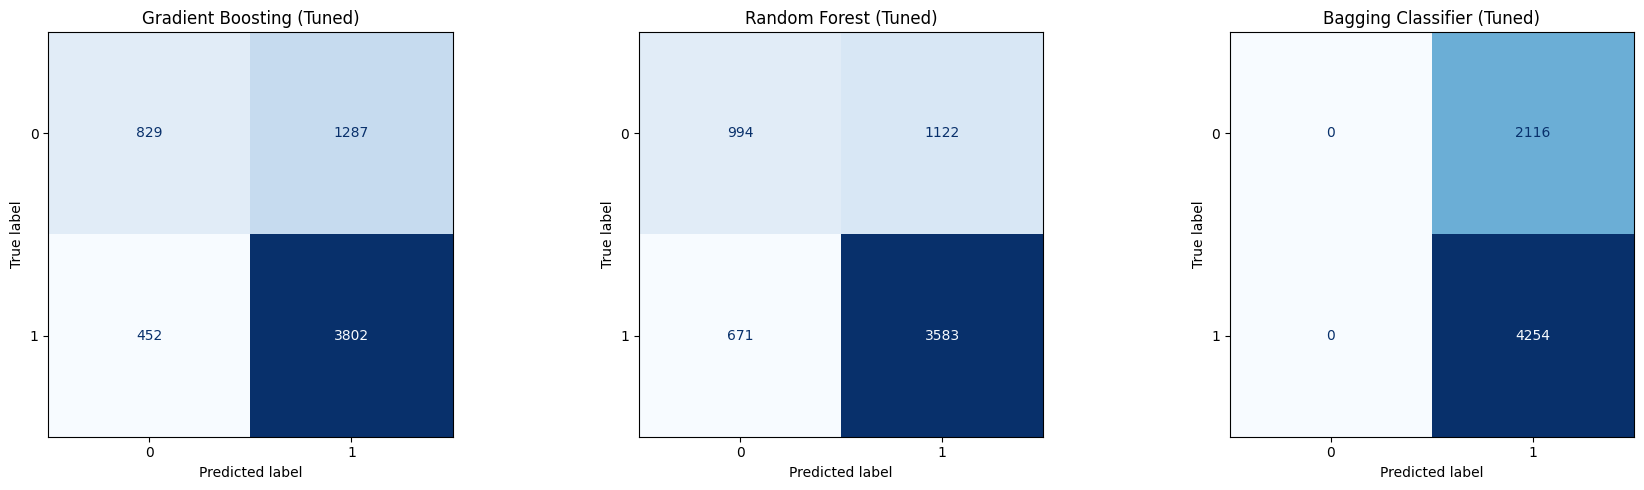

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

models = {
    "Gradient Boosting (Tuned)": y_pred_gb,
    "Random Forest (Tuned)": y_pred_rf,
    "Bagging Classifier (Tuned)": y_pred_bag
}

plt.figure(figsize=(18, 5))

for i, (name, preds) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d', ax=plt.gca(), colorbar=False)
    plt.title(name)

plt.tight_layout()
plt.show()


# Final Model selection

* The best model from the above comparison is **Gradient Boosting**

* After tuning Gradient Boosting, Random Forest, and Bagging Classifier, the tuned Gradient Boosting model achieved the best overall performance. It delivered the highest F1‑score and accuracy while maintaining a very high recall, which aligns with the business objective of minimizing false negatives.

Although Bagging achieved a recall of 1.0, it showed signs of overfitting, with low precision and reduced accuracy. Random Forest performed well but did not surpass Gradient Boosting.

Therefore, the final selected model for deployment is the Tuned Gradient Boosting Classifier

# **Actionable Insights**

* The primary business objective of this project is to minimize false negatives — cases where the model predicts “Certified” but the actual outcome is “Denied.” Such errors can lead to compliance risks and misinformed decision‑making. Therefore, Recall is the most critical metric, followed by F1‑score, which balances recall and precision.

* After hyperparameter tuning, the three candidate models were evaluated on the test set:

* Gradient Boosting (Tuned) achieved the best overall balance, with a high recall of 0.8937, the highest F1‑score (0.8139), and the highest accuracy (0.7270).

* Random Forest (Tuned) performed well with a recall of 0.8423 and strong precision, but did not surpass Gradient Boosting.

* Bagging Classifier (Tuned) achieved a perfect recall of 1.0, but its precision and accuracy dropped significantly, indicating overfitting and making it unsuitable for deployment.

* Based on the combined evaluation of recall, F1 score, precision, and generalization performance, the Tuned Gradient Boosting Classifier is recommended as the final model for deployment. It provides the most reliable and balanced performance while effectively minimizing false negatives, aligning directly with the business objective.   



# Business Recommendations

Based on the tuned Gradient Boosting model, applicants with higher wages, strong educational backgrounds, relevant job experience, full time employment, and positions in high demand regions are more likely to be certified. Conversely, applicants with low wages, limited education, no relevant experience, part time roles, employment in low demand regions, or small/new employers are more likely to be denied.